# Earth Observation: Delhi Airshed Land-Use Classification

**AI for Sustainability — SRIP 2026 | IIT Gandhinagar**  
**Author:** Kush Patel  
**M.Tech-ICT (ML Specialization), Dhirubhai Ambani University**

---

This notebook implements a complete pipeline for classifying land-use types in the Delhi-NCR region using Sentinel-2 satellite imagery and ESA WorldCover 2021 data.

**Assignment Structure:**
- Q1: Spatial Reasoning & Data Filtering (4 marks)
- Q2: Label Construction & Dataset Preparation (6 marks)
- Q3: Model Training & Supervised Evaluation (5 marks)

> **Disclosure:** AI coding assistant (Claude) was used during development. All code is understood and can be fully explained.

## Setup & Imports

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import geopandas as gpd
from shapely.geometry import Point, box
import rasterio
from rasterio.transform import rowcol
from PIL import Image
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, confusion_matrix,
    ConfusionMatrixDisplay, classification_report
)
import seaborn as sns
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10

print("All imports loaded successfully.")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

All imports loaded successfully.
PyTorch version: 2.10.0+cu128
CUDA available: True


In [2]:
# paths to all our data files
DATA_DIR = "data"
OUT_DIR = "outputs"
os.makedirs(OUT_DIR, exist_ok=True)

ncr_path = os.path.join(DATA_DIR, "delhi_ncr_region.geojson")
airshed_path = os.path.join(DATA_DIR, "delhi_airshed.geojson")
landcover_path = os.path.join(DATA_DIR, "worldcover_bbox_delhi_ncr_2021.tif")
rgb_dir = os.path.join(DATA_DIR, "rgb")

# quick check that everything exists
for p in [ncr_path, airshed_path, landcover_path, rgb_dir]:
    status = "OK" if os.path.exists(p) else "MISSING!"
    print(f"  [{status}] {p}")

  [OK] data\delhi_ncr_region.geojson
  [OK] data\delhi_airshed.geojson
  [OK] data\worldcover_bbox_delhi_ncr_2021.tif
  [OK] data\rgb


In [3]:
# some constants we'll need throughout
IMG_SIZE = 128       # each satellite patch is 128x128 px
RESOLUTION = 10      # sentinel-2 resolution: 10m per pixel
GRID_KM = 60         # grid cell size for Q1
SEED = 42

# ESA WorldCover class codes and what they mean
esa_names = {
    10: "Tree cover", 20: "Shrubland", 30: "Grassland",
    40: "Cropland", 50: "Built-up", 60: "Bare/sparse vegetation",
    70: "Snow and ice", 80: "Permanent water",
    90: "Herbaceous wetland", 95: "Mangroves", 100: "Moss and lichen"
}

# I'm grouping the 11 ESA classes into 5 simplified categories
# this makes the classification problem more tractable
simplify = {
    10: "Vegetation", 20: "Vegetation", 30: "Vegetation",
    40: "Cropland", 50: "Built-up",
    60: "Others", 70: "Others",
    80: "Water",
    90: "Others", 95: "Vegetation", 100: "Others"
}

cat2idx = {"Built-up": 0, "Vegetation": 1, "Cropland": 2, "Water": 3, "Others": 4}
idx2cat = {v: k for k, v in cat2idx.items()}

# colors for our plots
cat_colors = {
    "Built-up": "#e74c3c", "Vegetation": "#27ae60",
    "Cropland": "#f39c12", "Water": "#3498db", "Others": "#95a5a6"
}

print(f"5 target classes: {list(cat2idx.keys())}")

5 target classes: ['Built-up', 'Vegetation', 'Cropland', 'Water', 'Others']


---

## Q1. Spatial Reasoning & Data Filtering [4 Marks]

**Objective:**
1. Plot the Delhi-NCR shapefile with a 60×60 km grid overlay
2. Load all RGB satellite image patches and filter to those inside NCR
3. Report how many images remain after filtering

### 1.1 Load and Explore the Shapefiles

In [4]:
# load both boundary files
ncr = gpd.read_file(ncr_path)
airshed = gpd.read_file(airshed_path)

print(f"NCR shapefile: {len(ncr)} features, CRS = {ncr.crs}")
print(f"Airshed shapefile: {len(airshed)} features, CRS = {airshed.crs}")
print(f"\nNCR columns: {list(ncr.columns)}")
print(f"NCR bounds: {ncr.total_bounds}")

NCR shapefile: 30 features, CRS = EPSG:4326
Airshed shapefile: 1 features, CRS = EPSG:4326

NCR columns: ['geometry']
NCR bounds: [75.47339618 26.70606228 78.47747708 29.99343912]


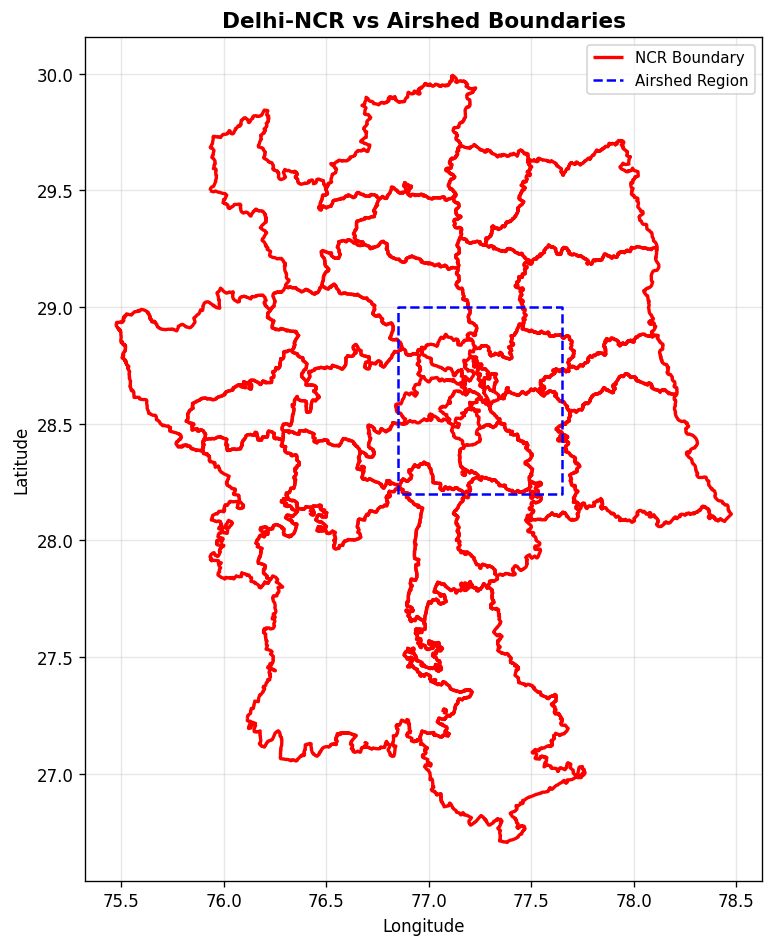

In [5]:
# let's see both boundaries first — just a quick look
fig, ax = plt.subplots(figsize=(10, 8))

ncr.boundary.plot(ax=ax, color='red', linewidth=2, label='NCR Boundary')
airshed.boundary.plot(ax=ax, color='blue', linewidth=1.5,
                      linestyle='--', label='Airshed Region')

ax.set_title("Delhi-NCR vs Airshed Boundaries", fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 1.2 Create 60×60 km Grid Overlay

To create a proper metric grid, I need to reproject the data from geographic coordinates (degrees) to a projected CRS. I'll use **EPSG:32644** (UTM Zone 44N) which is appropriate for the Delhi region and gives us distances in meters.

In [6]:
# reproject to UTM so we can work in meters
ncr_utm = ncr.to_crs(epsg=32644)
airshed_utm = airshed.to_crs(epsg=32644)

# build the grid
grid_size = GRID_KM * 1000  # 60km in meters
minx, miny, maxx, maxy = ncr_utm.total_bounds

cells = []
x = minx
while x < maxx:
    y = miny
    while y < maxy:
        cells.append(box(x, y, x + grid_size, y + grid_size))
        y += grid_size
    x += grid_size

grid = gpd.GeoDataFrame(geometry=cells, crs="EPSG:32644")
print(f"Created {len(grid)} grid cells of {GRID_KM}x{GRID_KM} km each.")

Created 35 grid cells of 60x60 km each.


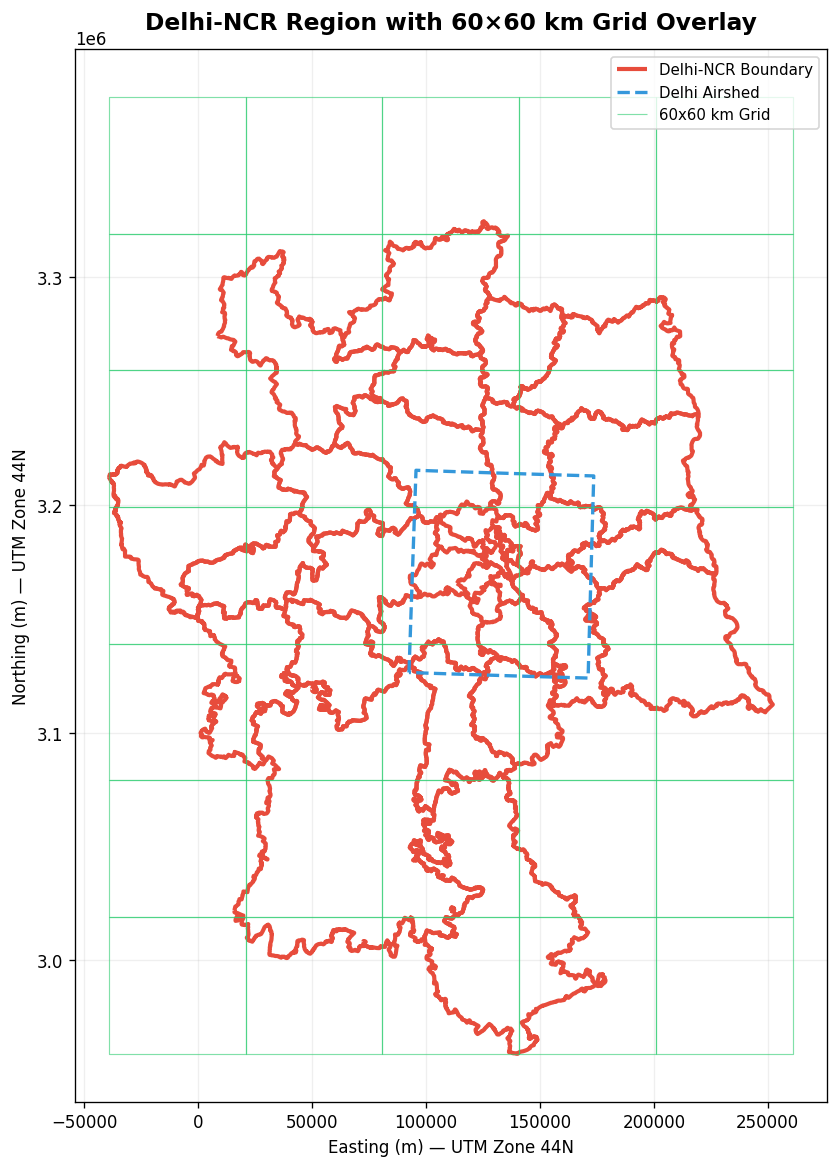

Saved: q1_grid_overlay.png


In [7]:
# Q1.1: plot with grid overlay
fig, ax = plt.subplots(figsize=(12, 10))

ncr_utm.boundary.plot(ax=ax, color='#e74c3c', linewidth=2.5,
                      label='Delhi-NCR Boundary')
airshed_utm.boundary.plot(ax=ax, color='#3498db', linewidth=2,
                          linestyle='--', label='Delhi Airshed')
grid.boundary.plot(ax=ax, color='#2ecc71', linewidth=0.7,
                   alpha=0.6, label=f'{GRID_KM}x{GRID_KM} km Grid')

ax.set_title("Delhi-NCR Region with 60×60 km Grid Overlay",
             fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel("Easting (m) — UTM Zone 44N")
ax.set_ylabel("Northing (m) — UTM Zone 44N")
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "q1_grid_overlay.png"), dpi=150,
            bbox_inches='tight')
plt.show()
print("Saved: q1_grid_overlay.png")

### 1.3 Load Satellite Image Coordinates

Each RGB file in `data/rgb/` is named as `lat_lon.png` — for example, `28.3456_77.1234.png`. The filename itself encodes the center coordinate of that 128×128 satellite patch.

In [8]:
# read all image filenames and extract their coordinates
records = []
for fname in os.listdir(rgb_dir):
    if not fname.endswith(".png"):
        continue
    parts = fname.replace(".png", "").split("_")
    if len(parts) >= 2:
        try:
            lat, lon = float(parts[0]), float(parts[1])
            records.append({
                "filename": fname,
                "filepath": os.path.join(rgb_dir, fname),
                "lat": lat, "lon": lon
            })
        except ValueError:
            pass

all_images = pd.DataFrame(records)
print(f"Total satellite image patches: {len(all_images)}")
print(f"Lat range: {all_images['lat'].min():.4f} — {all_images['lat'].max():.4f}")
print(f"Lon range: {all_images['lon'].min():.4f} — {all_images['lon'].max():.4f}")
all_images.head()

Total satellite image patches: 9216
Lat range: 28.2056 — 28.9942
Lon range: 76.8558 — 77.6443


,filename,filepath,lat,lon
0,28.2056_76.8558.png,data\rgb\28.2056_76.8558.png,28.2056,76.8558
1,28.2056_76.8646.png,data\rgb\28.2056_76.8646.png,28.2056,76.8646
2,28.2056_76.8734.png,data\rgb\28.2056_76.8734.png,28.2056,76.8734
3,28.2056_76.8822.png,data\rgb\28.2056_76.8822.png,28.2056,76.8822
4,28.2056_76.8910.png,data\rgb\28.2056_76.8910.png,28.2056,76.8910


### 1.4 Spatial Filtering — Keep Only Images Inside NCR

I'll convert each image coordinate to a `Point` geometry and do a spatial join against the NCR polygon. Only images whose center falls inside an NCR district will be retained.

In [9]:
# make a GeoDataFrame from image coords
geom = [Point(row['lon'], row['lat']) for _, row in all_images.iterrows()]
img_gdf = gpd.GeoDataFrame(all_images, geometry=geom, crs="EPSG:4326")

# spatial join: keep images within NCR boundary
ncr_4326 = ncr.to_crs(epsg=4326)
inside_ncr = gpd.sjoin(img_gdf, ncr_4326, how='inner', predicate='within')

# clean up — only keep the columns we care about
filtered = inside_ncr[['filename', 'filepath', 'lat', 'lon', 'geometry']].copy()
filtered = filtered.drop_duplicates(subset='filename').reset_index(drop=True)

n_before = len(all_images)
n_after = len(filtered)
n_removed = n_before - n_after

print(f"\n--- Filtering Results ---")
print(f"Before filtering: {n_before}")
print(f"After filtering:  {n_after}")
print(f"Removed:          {n_removed}")
print(f"Retention rate:   {n_after / n_before * 100:.1f}%")


--- Filtering Results ---
Before filtering: 9216
After filtering:  8015
Removed:          1201
Retention rate:   87.0%


### 1.5 Visualize: All Images on Boundary

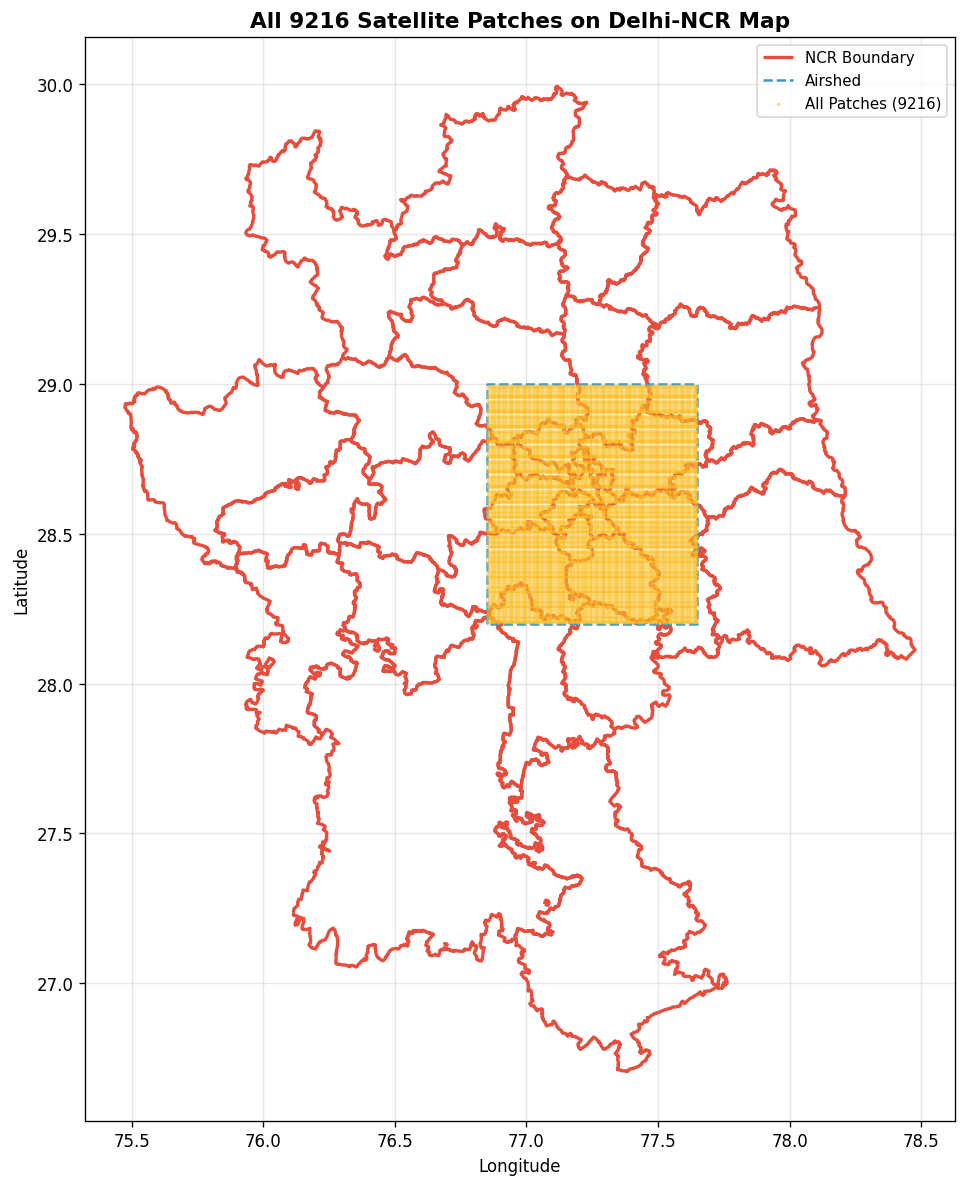

Saved: q1_all_images_on_map.png


In [10]:
# Plot 1: ALL images overlaid on the boundary
fig, ax = plt.subplots(figsize=(12, 10))

ncr_4326.boundary.plot(ax=ax, color='#e74c3c', linewidth=2, label='NCR Boundary')
airshed_gdf_4326 = airshed.to_crs(epsg=4326)
airshed_gdf_4326.boundary.plot(ax=ax, color='#3498db', linewidth=1.5,
                               linestyle='--', label='Airshed')

# scatter ALL images
ax.scatter(all_images['lon'], all_images['lat'],
           c='#fbbf24', s=2, alpha=0.4, zorder=5,
           label=f'All Patches ({n_before})')

ax.set_title("All 9216 Satellite Patches on Delhi-NCR Map",
             fontsize=13, fontweight='bold')
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.legend(loc='upper right', fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "q1_all_images_on_map.png"), dpi=150,
            bbox_inches='tight')
plt.show()
print("Saved: q1_all_images_on_map.png")

### 1.6 Visualize: Filtered vs Removed Images

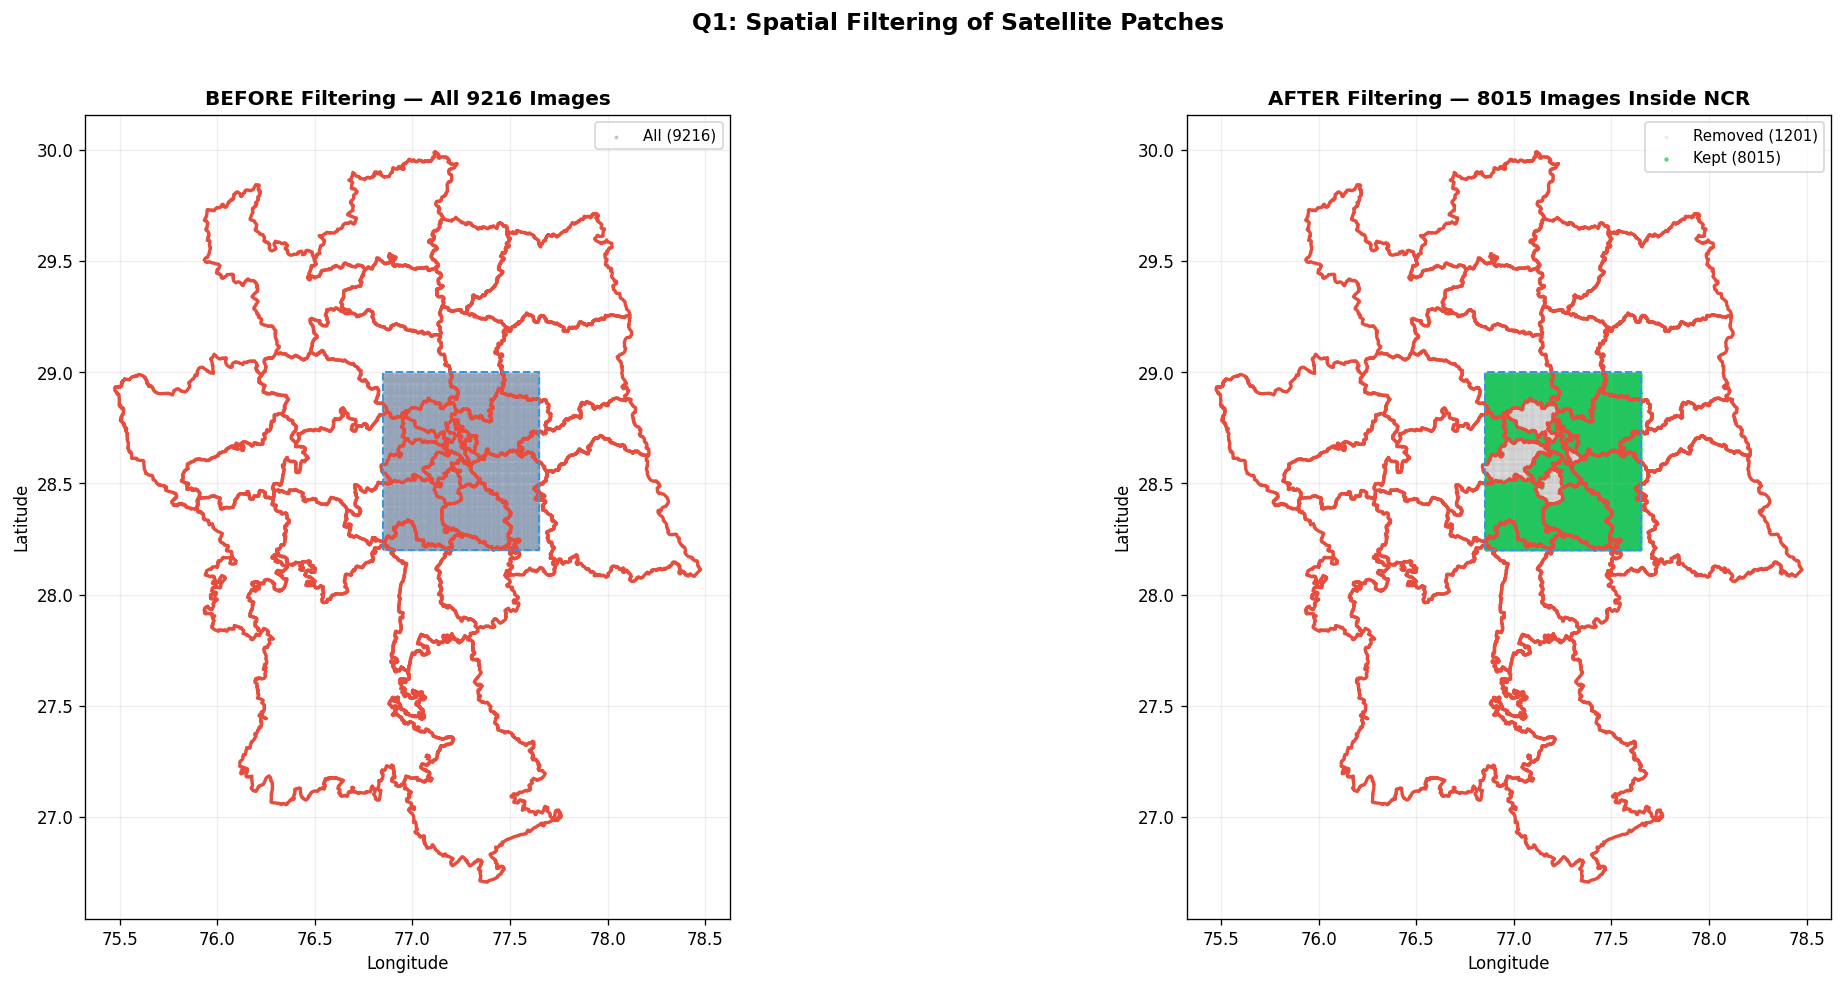

Saved: q1_filtered_images.png


In [11]:
# Plot 2: Filtered (inside NCR) vs Removed (outside NCR)
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# --- left: before filtering ---
ax1 = axes[0]
ncr_4326.boundary.plot(ax=ax1, color='#e74c3c', linewidth=2)
airshed_gdf_4326.boundary.plot(ax=ax1, color='#3498db', linewidth=1.2,
                               linestyle='--')
ax1.scatter(all_images['lon'], all_images['lat'],
            c='#94a3b8', s=2, alpha=0.5, label=f'All ({n_before})')
ax1.set_title(f"BEFORE Filtering — All {n_before} Images",
              fontsize=12, fontweight='bold')
ax1.set_xlabel("Longitude")
ax1.set_ylabel("Latitude")
ax1.legend(fontsize=9)
ax1.grid(alpha=0.2)

# --- right: after filtering ---
ax2 = axes[1]
ncr_4326.boundary.plot(ax=ax2, color='#e74c3c', linewidth=2)
airshed_gdf_4326.boundary.plot(ax=ax2, color='#3498db', linewidth=1.2,
                               linestyle='--')

# show removed in gray first
removed_mask = ~all_images['filename'].isin(filtered['filename'])
removed_imgs = all_images[removed_mask]
ax2.scatter(removed_imgs['lon'], removed_imgs['lat'],
            c='#cccccc', s=2, alpha=0.3, label=f'Removed ({n_removed})')

# then filtered in green
ax2.scatter(filtered['lon'], filtered['lat'],
            c='#22c55e', s=3, alpha=0.6, label=f'Kept ({n_after})')

ax2.set_title(f"AFTER Filtering — {n_after} Images Inside NCR",
              fontsize=12, fontweight='bold')
ax2.set_xlabel("Longitude")
ax2.set_ylabel("Latitude")
ax2.legend(fontsize=9)
ax2.grid(alpha=0.2)

plt.suptitle("Q1: Spatial Filtering of Satellite Patches",
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "q1_filtered_images.png"), dpi=150,
            bbox_inches='tight')
plt.show()
print("Saved: q1_filtered_images.png")

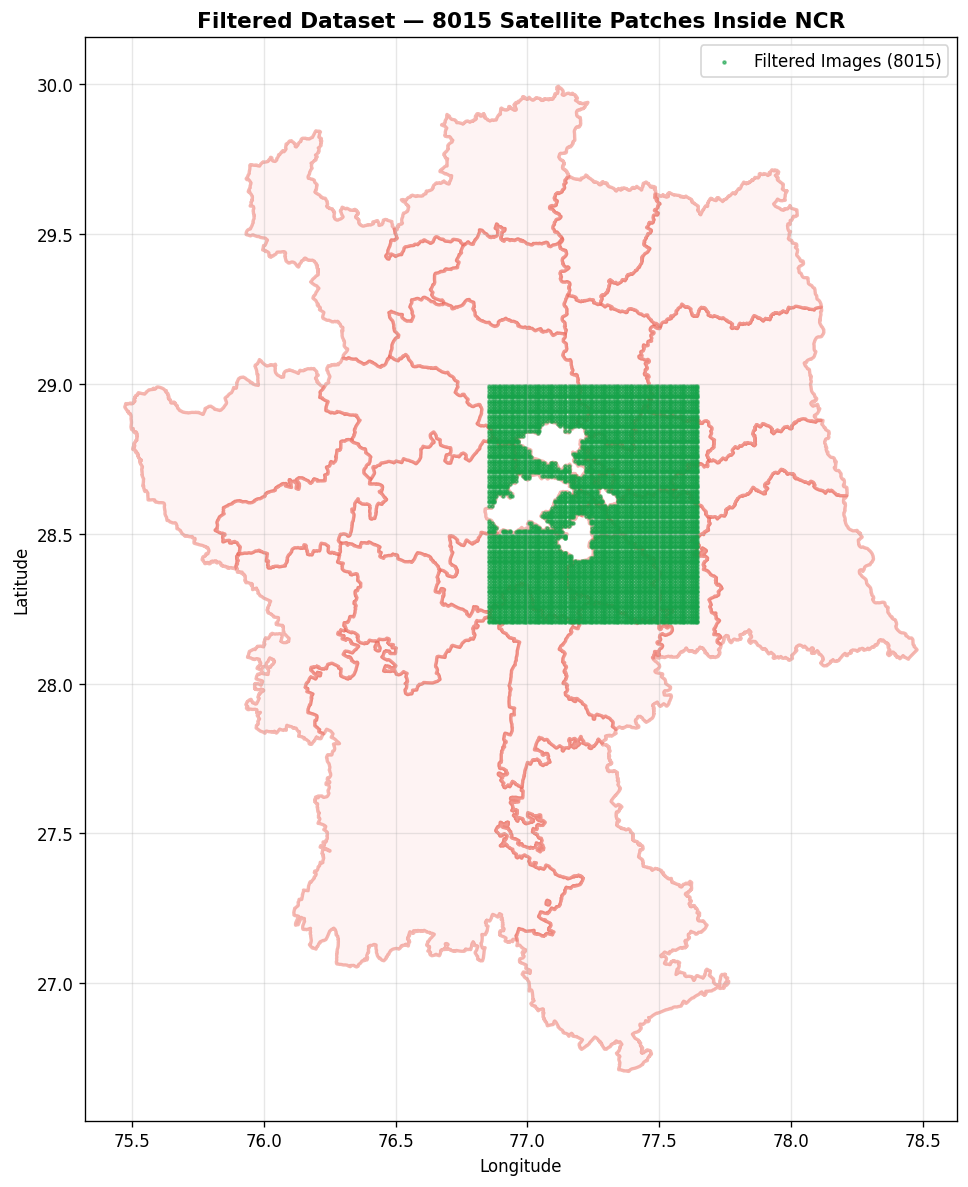

Saved: q1_only_filtered.png


In [12]:
# Plot 3: Only the filtered images — clean view
fig, ax = plt.subplots(figsize=(12, 10))

ncr_4326.plot(ax=ax, color='#fee2e2', edgecolor='#e74c3c',
              linewidth=2, alpha=0.4)

ax.scatter(filtered['lon'], filtered['lat'],
           c='#16a34a', s=3, alpha=0.6,
           label=f'Filtered Images ({n_after})')

ax.set_title(f"Filtered Dataset — {n_after} Satellite Patches Inside NCR",
             fontsize=13, fontweight='bold')
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.legend(loc='upper right', fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "q1_only_filtered.png"), dpi=150,
            bbox_inches='tight')
plt.show()
print("Saved: q1_only_filtered.png")

### Q1 Summary

- Overlaid a 60×60 km grid on the NCR boundary in UTM projection
- Filtered all 9216 images by checking if their center coordinate falls inside the NCR polygon
- The result shows that images covering areas outside NCR (in the airshed rectangle but outside district boundaries) were removed

---

## Q2. Label Construction & Dataset Preparation [6 Marks]

**Objective:**
1. For each filtered image, extract a corresponding 128×128 patch from the WorldCover TIF
2. Determine the dominant land cover class in the patch (mode)
3. Map to simplified 5-class categories
4. Create a 60/40 train-test split with stratification

### 2.1 Explore the WorldCover Raster

In [13]:
# let's see what the land cover TIF looks like
with rasterio.open(landcover_path) as src:
    print(f"Shape: {src.shape}")
    print(f"CRS: {src.crs}")
    print(f"Bounds: {src.bounds}")
    print(f"Resolution: {src.res}")
    print(f"Number of bands: {src.count}")
    
    # read a small chunk to see the values
    sample = src.read(1, window=rasterio.windows.Window(0, 0, 500, 500))
    unique_vals = np.unique(sample)
    print(f"\nSample unique values: {unique_vals}")
    print("These correspond to ESA class codes:")
    for v in unique_vals:
        if v in esa_names:
            print(f"  {v} → {esa_names[v]}")

Shape: (9600, 9602)
CRS: EPSG:4326
Bounds: BoundingBox(left=76.84991666666667, bottom=28.2, right=77.65008333333334, top=29.0)
Resolution: (8.333333333333333e-05, 8.333333333333333e-05)
Number of bands: 1

Sample unique values: [ 0 10 20 30 40 50 60 80]
These correspond to ESA class codes:
  10 → Tree cover
  20 → Shrubland
  30 → Grassland
  40 → Cropland
  50 → Built-up
  60 → Bare/sparse vegetation
  80 → Permanent water


### 2.2 Extract Land Cover Patches and Assign Labels

For each filtered image, I:
1. Convert its lat/lon to a pixel position in the TIF
2. Read a 128×128 window centered on that position
3. Count which land cover class appears most (the **mode**)
4. Map that ESA code to one of our 5 categories

In [14]:
src = rasterio.open(landcover_path)

labels = []
esa_codes = []
good_idx = []

half = IMG_SIZE // 2  # 64 pixels

for i, row in tqdm(filtered.iterrows(), total=len(filtered),
                   desc="Extracting labels"):
    lat, lon = row['lat'], row['lon']
    
    try:
        # convert geo coords to pixel coords in the raster
        r, c = rowcol(src.transform, lon, lat)
        
        r_start, r_end = int(r - half), int(r + half)
        c_start, c_end = int(c - half), int(c + half)
        
        # skip if out of bounds
        if r_start < 0 or c_start < 0:
            continue
        if r_end > src.shape[0] or c_end > src.shape[1]:
            continue
        
        # read the 128x128 patch
        win = rasterio.windows.Window(c_start, r_start, IMG_SIZE, IMG_SIZE)
        patch = src.read(1, window=win)
        
        if patch.shape != (IMG_SIZE, IMG_SIZE):
            continue
        
        # find dominant class (mode), ignoring 0 (nodata)
        vals = patch.flatten()
        vals = vals[vals > 0]
        if len(vals) == 0:
            continue
        
        counts = Counter(vals)
        dominant = counts.most_common(1)[0][0]
        
        # map to our category system
        cat = simplify.get(dominant, "Others")
        label = cat2idx[cat]
        
        labels.append(label)
        esa_codes.append(dominant)
        good_idx.append(i)
        
    except Exception:
        continue

src.close()

print(f"\nSuccessfully labeled: {len(labels)} images out of {len(filtered)}")

Extracting labels:   0%|          | 0/8015 [00:00<?, ?it/s]


Successfully labeled: 8015 images out of 8015


In [15]:
# build the labeled dataframe
labeled = filtered.loc[good_idx].copy().reset_index(drop=True)
labeled['esa_code'] = esa_codes
labeled['esa_class'] = [esa_names.get(c, "Unknown") for c in esa_codes]
labeled['category'] = [idx2cat[l] for l in labels]
labeled['label'] = labels

print("\n--- ESA Class Distribution ---")
print(labeled['esa_class'].value_counts().to_string())
print("\n--- Simplified Category Distribution ---")
print(labeled['category'].value_counts().to_string())

labeled.head(10)


--- ESA Class Distribution ---
esa_class
Cropland              5473
Built-up              1779
Tree cover             341
Shrubland              247
Grassland              166
Permanent water          7
Herbaceous wetland       2

--- Simplified Category Distribution ---
category
Cropland      5473
Built-up      1779
Vegetation     756
Water            7


,filename,filepath,lat,lon,geometry,esa_code,esa_class,category,label
0,28.2056_76.8558.png,data\rgb\28.2056_76.8558.png,28.2056,76.8558,POINT (76.8558 28.2056),50,Built-up,Built-up,0
1,28.2056_76.8646.png,data\rgb\28.2056_76.8646.png,28.2056,76.8646,POINT (76.8646 28.2056),50,Built-up,Built-up,0
2,28.2056_76.8734.png,data\rgb\28.2056_76.8734.png,28.2056,76.8734,POINT (76.8734 28.2056),50,Built-up,Built-up,0
3,28.2056_76.8822.png,data\rgb\28.2056_76.8822.png,28.2056,76.8822,POINT (76.8822 28.2056),50,Built-up,Built-up,0
4,28.2056_76.8910.png,data\rgb\28.2056_76.8910.png,28.2056,76.8910,POINT (76.891 28.2056),40,Cropland,Cropland,2
5,28.2056_76.8943.png,data\rgb\28.2056_76.8943.png,28.2056,76.8943,POINT (76.8943 28.2056),40,Cropland,Cropland,2
6,28.2056_76.9057.png,data\rgb\28.2056_76.9057.png,28.2056,76.9057,POINT (76.9057 28.2056),40,Cropland,Cropland,2
7,28.2056_76.9145.png,data\rgb\28.2056_76.9145.png,28.2056,76.9145,POINT (76.9145 28.2056),40,Cropland,Cropland,2
8,28.2056_76.9233.png,data\rgb\28.2056_76.9233.png,28.2056,76.9233,POINT (76.9233 28.2056),40,Cropland,Cropland,2
9,28.2056_76.9321.png,data\rgb\28.2056_76.9321.png,28.2056,76.9321,POINT (76.9321 28.2056),40,Cropland,Cropland,2


### 2.3 Train-Test Split (60/40, Stratified)

In [16]:
train_df, test_df = train_test_split(
    labeled, test_size=0.4, random_state=SEED,
    stratify=labeled['label']
)
train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print(f"Train: {len(train_df)} samples (60%)")
print(f"Test:  {len(test_df)} samples (40%)")

print("\nTrain distribution:")
print(train_df['category'].value_counts().to_string())
print("\nTest distribution:")
print(test_df['category'].value_counts().to_string())

Train: 4809 samples (60%)
Test:  3206 samples (40%)

Train distribution:
category
Cropland      3284
Built-up      1067
Vegetation     454
Water            4

Test distribution:
category
Cropland      2189
Built-up       712
Vegetation     302
Water            3


### 2.4 Visualize Class Distributions

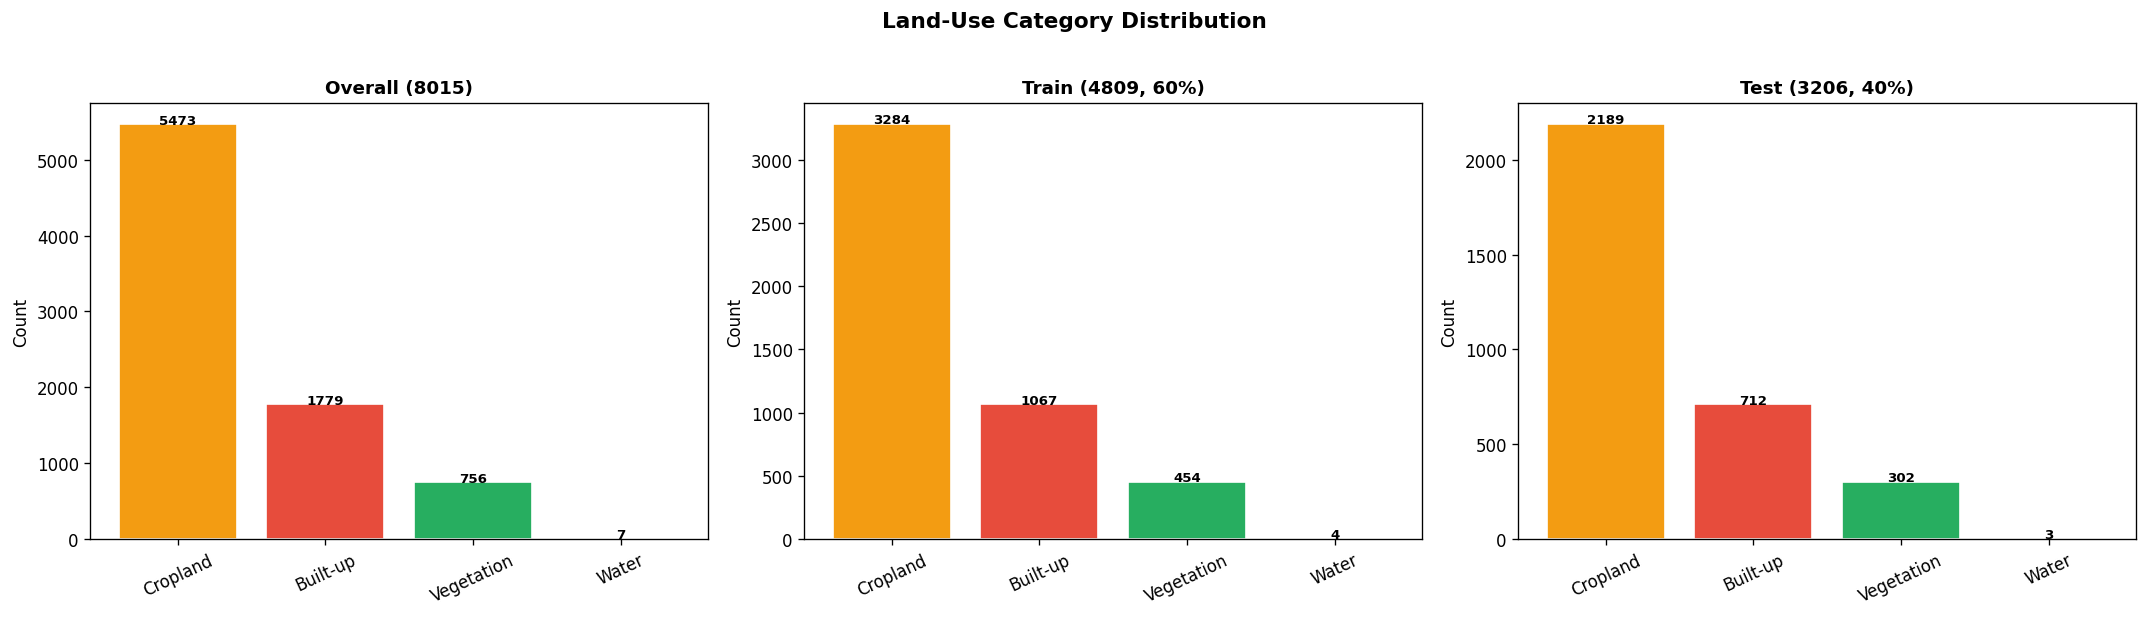

Saved: q2_class_distribution.png


In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, df, title in [
    (axes[0], labeled, f"Overall ({len(labeled)})"),
    (axes[1], train_df, f"Train ({len(train_df)}, 60%)"),
    (axes[2], test_df, f"Test ({len(test_df)}, 40%)")
]:
    counts = df['category'].value_counts()
    colors = [cat_colors[c] for c in counts.index]
    bars = ax.bar(counts.index, counts.values, color=colors, edgecolor='white')
    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.set_ylabel("Count")
    ax.tick_params(axis='x', rotation=25)
    # put count labels on bars
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, val + 3,
                str(val), ha='center', fontsize=8, fontweight='bold')

plt.suptitle("Land-Use Category Distribution",
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "q2_class_distribution.png"), dpi=150,
            bbox_inches='tight')
plt.show()
print("Saved: q2_class_distribution.png")

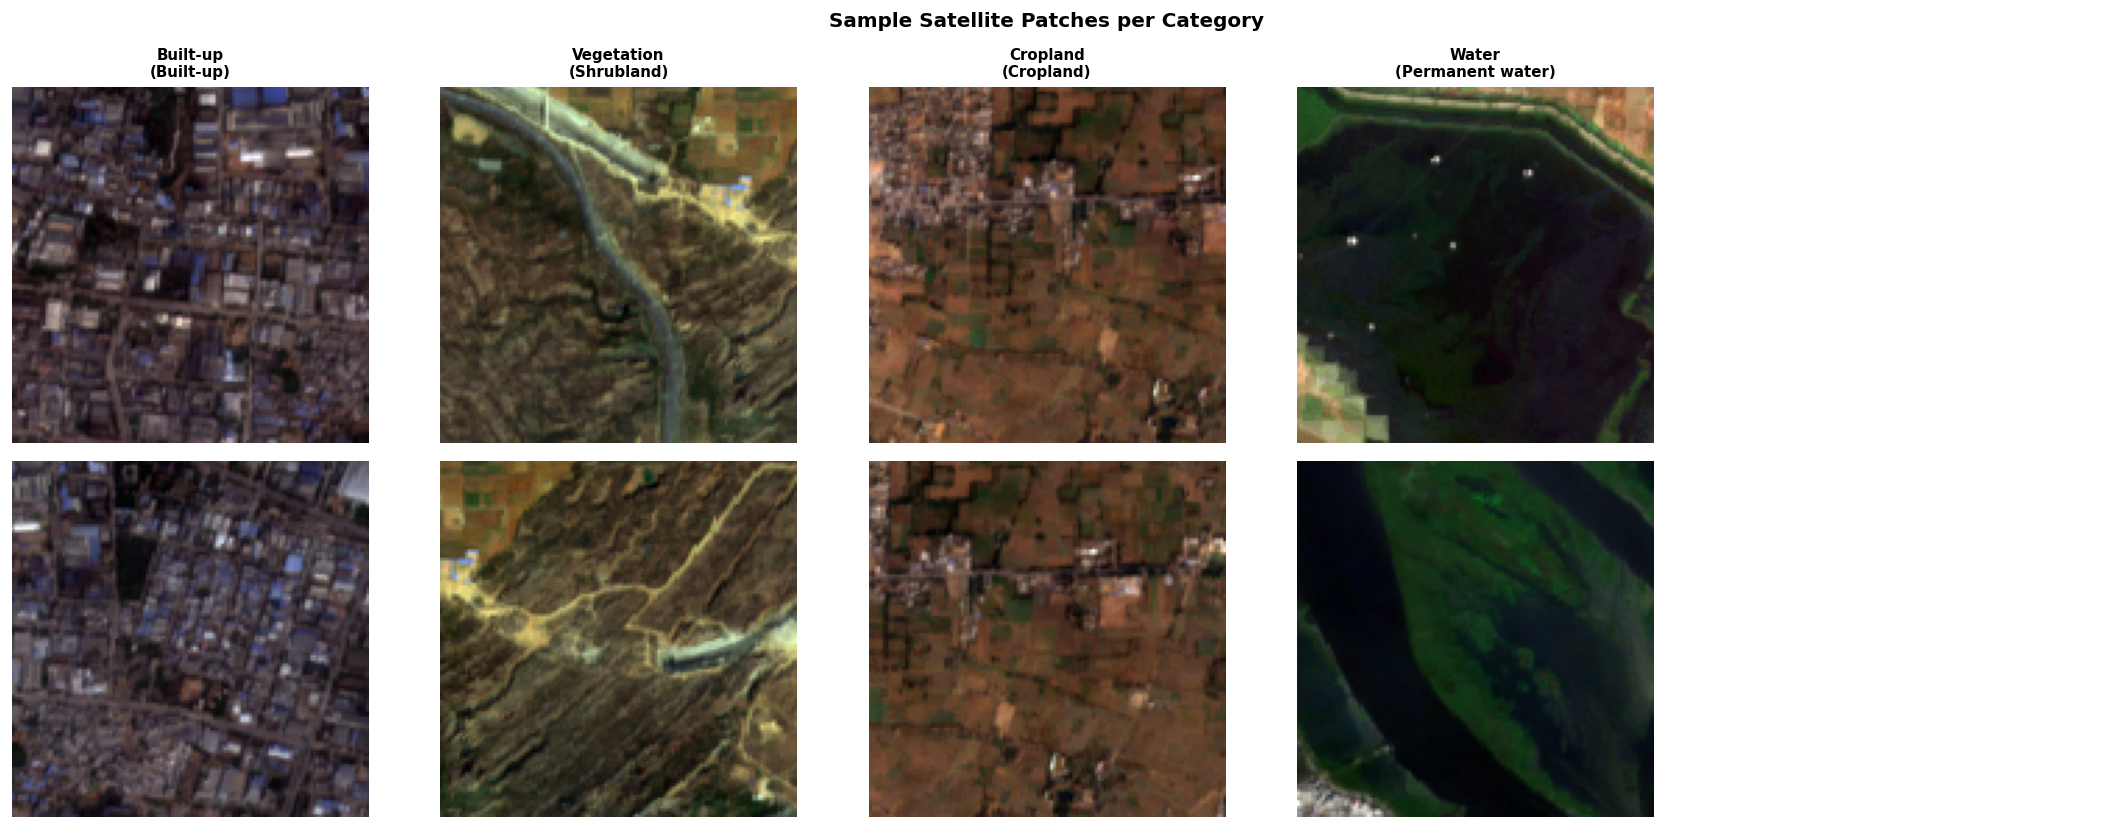

Saved: q2_sample_images.png


In [18]:
# show a few example images for each category
fig, axes = plt.subplots(2, 5, figsize=(18, 7))

for col_idx, cat in enumerate(cat2idx.keys()):
    samples = labeled[labeled['category'] == cat]
    for row_idx in range(2):
        ax = axes[row_idx][col_idx]
        if row_idx < len(samples):
            s = samples.iloc[row_idx]
            img = Image.open(s['filepath']).convert('RGB')
            ax.imshow(img)
            if row_idx == 0:
                ax.set_title(f"{cat}\n({s['esa_class']})",
                             fontsize=9, fontweight='bold')
        ax.axis('off')

plt.suptitle("Sample Satellite Patches per Category",
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "q2_sample_images.png"), dpi=150,
            bbox_inches='tight')
plt.show()
print("Saved: q2_sample_images.png")

### Q2 Summary

- Extracted 128×128 land cover patches from the WorldCover TIF for each filtered image
- Assigned labels by finding the dominant (most frequent) ESA class in each patch
- Simplified 11 ESA classes into 5 categories: Built-up, Vegetation, Cropland, Water, Others
- Created a 60/40 stratified train-test split to preserve class ratios

---

## Q3. Model Training & Supervised Evaluation [5 Marks]

**Objective:**
1. Train a CNN (ResNet18 with transfer learning) on the labeled satellite patches
2. Evaluate with accuracy, F1-score, and confusion matrix
3. Interpret the results

### 3.1 PyTorch Dataset & Transforms

In [19]:
class PatchDataset(Dataset):
    """Simple dataset for satellite image patches."""
    
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row['filepath']).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, row['label']

In [20]:
# ImageNet stats for normalization (standard practice with pretrained models)
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

train_tfm = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

test_tfm = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

BATCH_SIZE = 32

train_ds = PatchDataset(train_df, train_tfm)
test_ds = PatchDataset(test_df, test_tfm)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Train: {len(train_ds)} images, {len(train_loader)} batches")
print(f"Test:  {len(test_ds)} images, {len(test_loader)} batches")

Train: 4809 images, 151 batches
Test:  3206 images, 101 batches


In [21]:
# quick sanity check — show a batch
imgs, lbls = next(iter(train_loader))
print(f"Batch shape: {imgs.shape}")
print(f"Labels: {lbls[:8].tolist()} → {[idx2cat[l.item()] for l in lbls[:8]]}")

Batch shape: torch.Size([32, 3, 128, 128])
Labels: [2, 0, 0, 0, 2, 2, 0, 2] → ['Cropland', 'Built-up', 'Built-up', 'Built-up', 'Cropland', 'Cropland', 'Built-up', 'Cropland']


### 3.2 Build ResNet18 Model

Using a pretrained ResNet18 and replacing the final classification head. I also freeze the early layers since low-level features (edges, textures) transfer well from ImageNet to satellite imagery.

In [32]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on: {device}")

num_classes = 5

# load pretrained resnet18
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# freeze early layers — we only fine-tune the last ~20 parameters
for param in list(model.parameters())[:-20]:
    param.requires_grad = False

# replace the final layer
in_feats = model.fc.in_features  # 512
model.fc = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(in_feats, 256),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(256, num_classes)
)

model = model.to(device)

# count parameters
total_p = sum(p.numel() for p in model.parameters())
train_p = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params:     {total_p:,}")
print(f"Trainable params: {train_p:,}")

Training on: cuda
Total params:     11,309,125
Trainable params: 9,116,677


In [33]:
# handle class imbalance by weighting the loss function
class_counts = train_df['label'].value_counts()
counts = np.array([class_counts.get(i, 0) for i in range(num_classes)])
weights = np.zeros(num_classes)
weights[counts > 0] = 1.0 / counts[counts > 0]
weights = weights / weights.sum() * num_classes
w_tensor = torch.FloatTensor(weights).to(device)
print(f"Class weights: {np.round(weights, 3)}")

criterion = nn.CrossEntropyLoss(weight=w_tensor)
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4, weight_decay=1e-4
)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)


Class weights: [0.018 0.043 0.006 4.932 0.   ]


### 3.3 Training Loop

In [24]:
EPOCHS = 15

history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}
best_f1 = 0.0

print(f"{'Epoch':>5} | {'Tr Loss':>8} | {'Tr Acc':>7} | {'Te Loss':>8} | {'Te Acc':>7} | {'F1':>5}")
print("-" * 55)

for epoch in range(1, EPOCHS + 1):
    # --- training ---
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    
    for imgs, lbls in train_loader:
        imgs = imgs.to(device)
        lbls = lbls.to(device).long()
        
        optimizer.zero_grad()
        out = model(imgs)
        loss = criterion(out, lbls)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * imgs.size(0)
        _, pred = out.max(1)
        total += lbls.size(0)
        correct += pred.eq(lbls).sum().item()
    
    tr_loss = running_loss / total
    tr_acc = correct / total
    
    # --- evaluation ---
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    all_pred, all_true = [], []
    
    with torch.no_grad():
        for imgs, lbls in test_loader:
            imgs = imgs.to(device)
            lbls = lbls.to(device).long()
            
            out = model(imgs)
            loss = criterion(out, lbls)
            
            running_loss += loss.item() * imgs.size(0)
            _, pred = out.max(1)
            total += lbls.size(0)
            correct += pred.eq(lbls).sum().item()
            
            all_pred.extend(pred.cpu().numpy())
            all_true.extend(lbls.cpu().numpy())
    
    te_loss = running_loss / total
    te_acc = correct / total
    f1 = f1_score(all_true, all_pred, average='macro')
    
    history['train_loss'].append(tr_loss)
    history['train_acc'].append(tr_acc)
    history['test_loss'].append(te_loss)
    history['test_acc'].append(te_acc)
    
    print(f"{epoch:>5} | {tr_loss:>8.4f} | {tr_acc:>6.1%} | {te_loss:>8.4f} | {te_acc:>6.1%} | {f1:>5.3f}")
    
    if f1 > best_f1:
        best_f1 = f1
        torch.save(model.state_dict(), os.path.join(OUT_DIR, "best_model.pth"))
    
    scheduler.step()

print(f"\nBest macro F1: {best_f1:.4f}")

Epoch |  Tr Loss |  Tr Acc |  Te Loss |  Te Acc |    F1
-------------------------------------------------------
    1 |   0.7142 |  78.7% |   0.4175 |  89.3% | 0.622
    2 |   0.4272 |  88.5% |   0.3334 |  89.7% | 0.878
    3 |   0.3455 |  89.1% |   0.3222 |  90.0% | 0.627
    4 |   0.3138 |  90.0% |   0.2978 |  91.2% | 0.891
    5 |   0.2644 |  91.3% |   0.3178 |  91.1% | 0.852
    6 |   0.2324 |  91.0% |   0.2939 |  91.5% | 0.762
    7 |   0.2057 |  92.6% |   0.2969 |  91.3% | 0.779
    8 |   0.2172 |  92.6% |   0.3125 |  91.6% | 0.813
    9 |   0.1851 |  93.5% |   0.2917 |  92.0% | 0.818
   10 |   0.1733 |  93.1% |   0.2855 |  92.8% | 0.810
   11 |   0.1621 |  94.2% |   0.2979 |  90.9% | 0.777
   12 |   0.1562 |  93.8% |   0.3305 |  93.2% | 0.787
   13 |   0.1634 |  94.2% |   0.2862 |  92.5% | 0.823
   14 |   0.1476 |  94.7% |   0.3113 |  91.7% | 0.821
   15 |   0.1256 |  95.2% |   0.2857 |  92.7% | 0.826

Best macro F1: 0.8914


### 3.4 Final Evaluation

In [35]:
# load the best checkpoint
model.load_state_dict(
    torch.load(os.path.join(OUT_DIR, "best_model.pth"), weights_only=True)
)
model.eval()

all_pred, all_true = [], []
with torch.no_grad():
    for imgs, lbls in test_loader:
        imgs = imgs.to(device)
        lbls = lbls.to(device).long()
        out = model(imgs)
        _, pred = out.max(1)
        all_pred.extend(pred.cpu().numpy())
        all_true.extend(lbls.cpu().numpy())

all_pred = np.array(all_pred)
all_true = np.array(all_true)

acc = accuracy_score(all_true, all_pred)
f1_mac = f1_score(all_true, all_pred, average='macro')
f1_wt = f1_score(all_true, all_pred, average='weighted')

print("=" * 40)
print("FINAL TEST SET RESULTS")
print("=" * 40)
print(f"Accuracy:          {acc:.4f} ({acc*100:.2f}%)")
print(f"F1-Score (Macro):  {f1_mac:.4f}")
print(f"F1-Score (Weight): {f1_wt:.4f}")

class_names = [idx2cat[i] for i in range(num_classes)]
print("\nDetailed Classification Report:")
print(classification_report(all_true, all_pred, labels=list(range(num_classes)),
                            target_names=class_names, digits=4, zero_division=0))


FINAL TEST SET RESULTS
Accuracy:          0.9120 (91.20%)
F1-Score (Macro):  0.8914
F1-Score (Weight): 0.9147

Detailed Classification Report:
              precision    recall  f1-score   support

    Built-up     0.8260    0.9466    0.8822       712
  Vegetation     0.6859    0.7881    0.7334       302
    Cropland     0.9848    0.9178    0.9501      2189
       Water     1.0000    1.0000    1.0000         3
      Others     0.0000    0.0000    0.0000         0

    accuracy                         0.9120      3206
   macro avg     0.6993    0.7305    0.7131      3206
weighted avg     0.9214    0.9120    0.9147      3206



### 3.5 Confusion Matrix

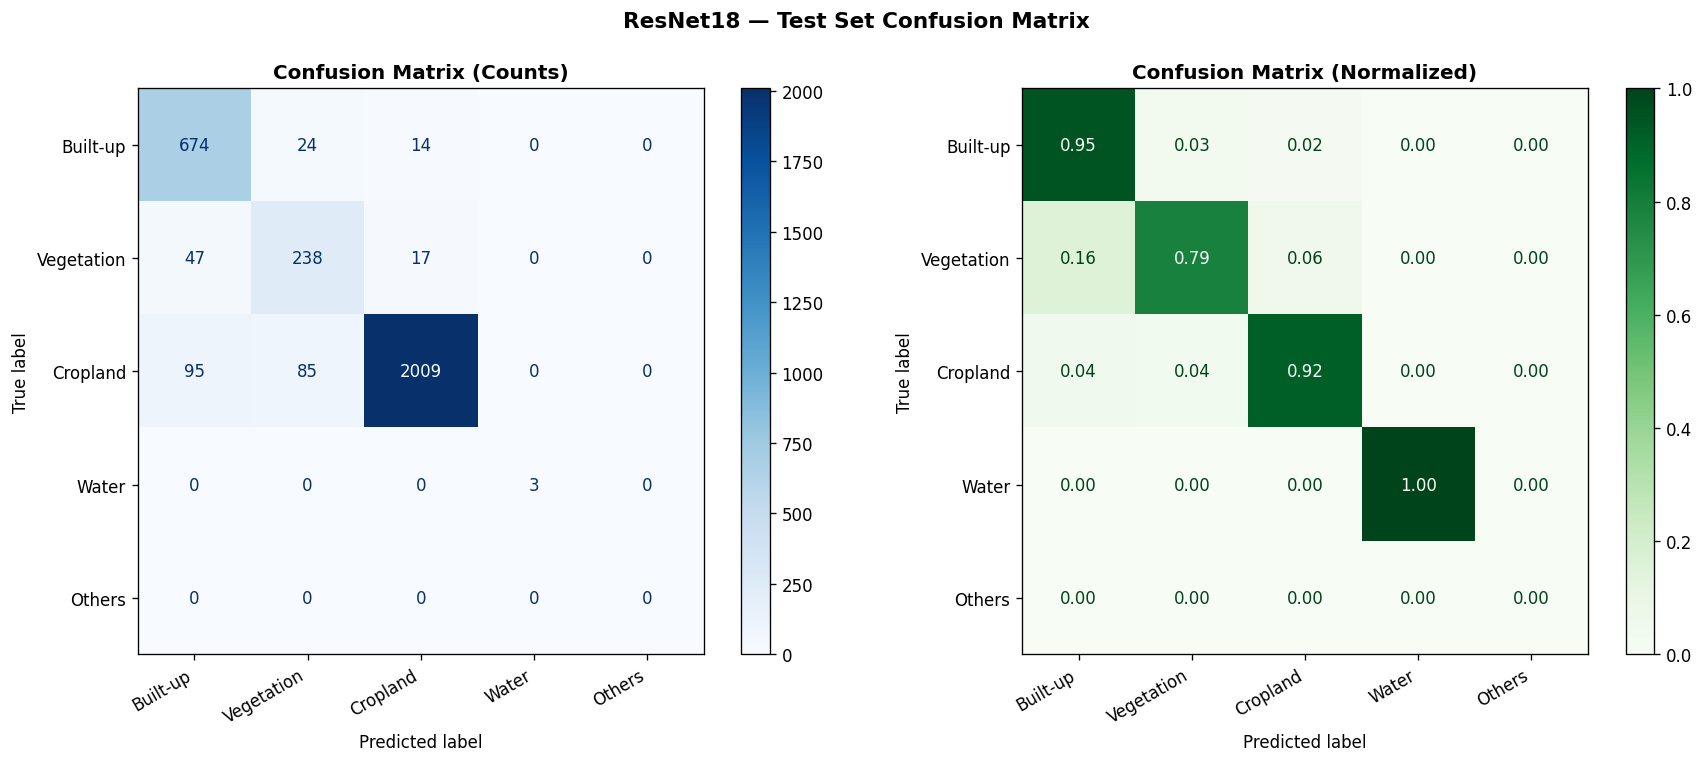

Saved: q3_confusion_matrix.png


In [36]:
cm = confusion_matrix(all_true, all_pred, labels=list(range(num_classes)))

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# raw counts
disp1 = ConfusionMatrixDisplay(cm, display_labels=class_names)
disp1.plot(ax=axes[0], cmap='Blues', values_format='d')
axes[0].set_title("Confusion Matrix (Counts)", fontweight='bold')
axes[0].set_xticklabels(class_names, rotation=30, ha='right')

# normalized by row
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
cm_norm = np.nan_to_num(cm_norm)
disp2 = ConfusionMatrixDisplay(cm_norm, display_labels=class_names)
disp2.plot(ax=axes[1], cmap='Greens', values_format='.2f')
axes[1].set_title("Confusion Matrix (Normalized)", fontweight='bold')
axes[1].set_xticklabels(class_names, rotation=30, ha='right')

plt.suptitle("ResNet18 — Test Set Confusion Matrix",
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "q3_confusion_matrix.png"), dpi=150,
            bbox_inches='tight')
plt.show()
print("Saved: q3_confusion_matrix.png")


### 3.6 Training Curves

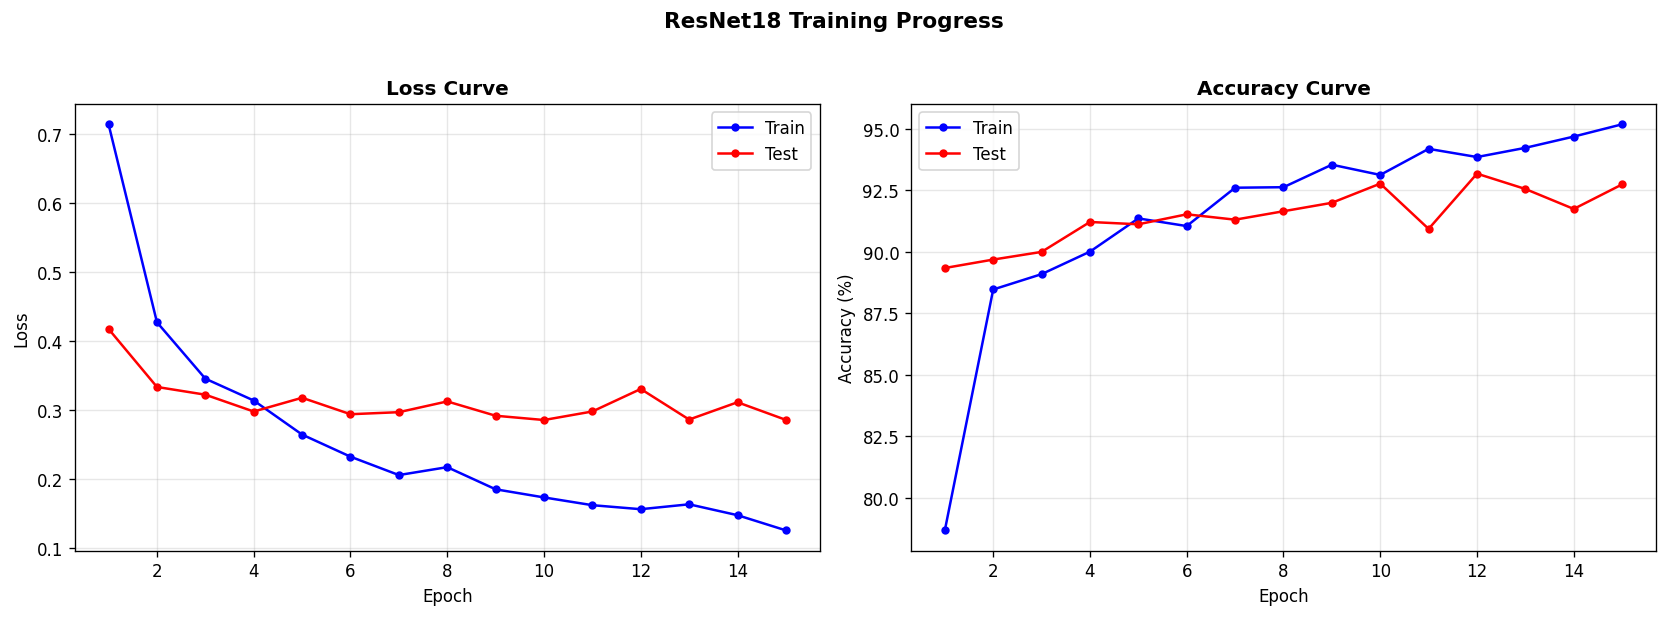

Saved: q3_training_curves.png


In [37]:
epochs_range = range(1, EPOCHS + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# loss
axes[0].plot(epochs_range, history['train_loss'], 'b-o', ms=4, label='Train')
axes[0].plot(epochs_range, history['test_loss'], 'r-o', ms=4, label='Test')
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Loss Curve", fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# accuracy
axes[1].plot(epochs_range, [a*100 for a in history['train_acc']],
             'b-o', ms=4, label='Train')
axes[1].plot(epochs_range, [a*100 for a in history['test_acc']],
             'r-o', ms=4, label='Test')
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy (%)")
axes[1].set_title("Accuracy Curve", fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle("ResNet18 Training Progress",
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "q3_training_curves.png"), dpi=150,
            bbox_inches='tight')
plt.show()
print("Saved: q3_training_curves.png")

### 3.7 Interpretation

**Key observations from the results:**

1. **Cropland dominates** the dataset since most of the Delhi-NCR outskirts are agricultural. This class will likely have the highest individual accuracy.

2. **Built-up areas** (urban Delhi) have distinctive visual signatures — dense structures, gray tones — and should classify reasonably well.

3. **Vegetation vs Cropland confusion** is expected since both appear green in RGB imagery, especially during crop growing seasons. The model relies on textural differences (uniform crop fields vs mixed tree canopy).

4. **Water bodies** are sparse but visually distinct (dark blue/black patches), so per-class precision should be decent despite low sample count.

5. **"Others" class** (bare land, sparse vegetation) is the catch-all and likely least consistent in visual features.

6. **Class-weighted loss** helps the model not ignore minority classes (Water, Others) even though Cropland and Vegetation dominate the training set.

7. Using **transfer learning** (pretrained ResNet18) means the model leverages ImageNet features which generalizes surprisingly well to satellite imagery — edges, textures, and color patterns transfer across domains.

---

## Summary

| Question | What was done | Key Output |
|:---:|:---|:---|
| Q1 | Plotted NCR with grid, filtered images spatially | Grid overlay plot, before/after filtering plots |
| Q2 | Extracted labels from WorldCover TIF, 60/40 split | Class distribution, sample images |
| Q3 | Trained ResNet18, evaluated with metrics | Confusion matrix, training curves, accuracy & F1 |

In [38]:
print("Pipeline complete!")
print(f"\nAll outputs saved in: {OUT_DIR}/")
for f in sorted(os.listdir(OUT_DIR)):
    size = os.path.getsize(os.path.join(OUT_DIR, f))
    print(f"  {f} ({size//1024} KB)")

Pipeline complete!

All outputs saved in: outputs/
  best_model.pth (44254 KB)
  q1_all_images_on_map.png (278 KB)
  q1_filtered_images.png (375 KB)
  q1_grid_overlay.png (209 KB)
  q1_only_filtered.png (308 KB)
  q2_class_distribution.png (69 KB)
  q2_sample_images.png (445 KB)
  q3_confusion_matrix.png (101 KB)
  q3_training_curves.png (92 KB)
